### **Cell 1 — Install Dependencies**

In [1]:
!pip install -q xgboost prophet shap statsmodels

### **Cell 2 — Imports**

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

np.random.seed(42)

### **Cell 3 — Load Data**

In [5]:
df = pd.read_csv("/kaggle/input/datasets/abdurrehman987t/karachi-daily-aqi-weather/karachi_daily_aqi_weather.csv")

df.head()

,date,AQI,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Precipitation,Next_Day_AQI
0,2023-01-01,129.583333,38.462500,69.537500,36.354167,33.379167,782.708333,84.916667,19.875000,65.375000,0.0,119.416667
1,2023-01-02,119.416667,59.991667,98.883333,47.241667,49.362500,905.708333,71.708333,19.725000,51.583333,0.0,153.000000
2,2023-01-03,153.000000,51.512500,77.683333,25.275000,27.154167,542.708333,80.125000,19.750000,36.458333,0.0,117.208333
3,2023-01-04,117.208333,40.720833,60.787500,18.004167,25.825000,466.625000,94.541667,18.866667,33.041667,0.0,119.958333
4,2023-01-05,119.958333,43.608333,63.775000,14.416667,28.462500,487.625000,103.041667,17.487500,31.666667,0.0,121.750000


### **Cell 4 — Create Targets**

In [6]:
df["aqi_t1"] = df["AQI"].shift(-1)
df["aqi_t2"] = df["AQI"].shift(-2)
df["aqi_t3"] = df["AQI"].shift(-3)

df = df.dropna().reset_index(drop=True)

print(df.shape)

(945, 15)


### **Cell 5 — Feature Selection**

In [7]:
FEATURE_COLS = [
    "AQI",
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "O3",
    "Temperature",
    "Humidity",
    "Precipitation"
]

TARGET_COLS = [
    "aqi_t1",
    "aqi_t2",
    "aqi_t3"
]

### **Cell 6 — Train/Test Split**

In [8]:
TEST_DAYS = 90

split_idx = len(df) - TEST_DAYS

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df[FEATURE_COLS].values
X_test = test_df[FEATURE_COLS].values

Y_train = train_df[TARGET_COLS].values
Y_test = test_df[TARGET_COLS].values

print(X_train.shape)
print(X_test.shape)

(855, 10)
(90, 10)


### **Cell 7 — Evaluation Functions**

In [9]:
def evaluate(Y_true, Y_pred, name):

    print(f"\n{name}")

    rmses = []

    for i, target in enumerate(TARGET_COLS):

        rmse = np.sqrt(
            mean_squared_error(
                Y_true[:, i],
                Y_pred[:, i]
            )
        )

        mae = mean_absolute_error(
            Y_true[:, i],
            Y_pred[:, i]
        )

        r2 = r2_score(
            Y_true[:, i],
            Y_pred[:, i]
        )

        rmses.append(rmse)

        print(
            f"{target}: "
            f"RMSE={rmse:.2f} "
            f"MAE={mae:.2f} "
            f"R2={r2:.4f}"
        )

    print(
        f"Average RMSE: {np.mean(rmses):.2f}"
    )

    return np.mean(rmses)

### **Cell 8 — Ridge Regression**

In [10]:
scaler = StandardScaler()

Xtr = scaler.fit_transform(X_train)
Xte = scaler.transform(X_test)

ridge = MultiOutputRegressor(
    Ridge(alpha=1.0)
)

ridge.fit(Xtr, Y_train)

ridge_pred = ridge.predict(Xte)

ridge_rmse = evaluate(
    Y_test,
    ridge_pred,
    "Ridge"
)


Ridge
aqi_t1: RMSE=5.14 MAE=3.89 R2=0.7989
aqi_t2: RMSE=9.95 MAE=8.04 R2=0.2343
aqi_t3: RMSE=12.03 MAE=9.70 R2=-0.0997
Average RMSE: 9.04


### **Cell 9 — Random Forest**

In [11]:
rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, Y_train)

rf_pred = rf.predict(X_test)

rf_rmse = evaluate(
    Y_test,
    rf_pred,
    "Random Forest"
)


Random Forest
aqi_t1: RMSE=5.02 MAE=3.60 R2=0.8077
aqi_t2: RMSE=9.87 MAE=7.63 R2=0.2461
aqi_t3: RMSE=12.22 MAE=9.46 R2=-0.1338
Average RMSE: 9.04


### **Cell 10 — XGBoost**

In [12]:
from xgboost import XGBRegressor

xgb = MultiOutputRegressor(

    XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )
)

xgb.fit(X_train, Y_train)

xgb_pred = xgb.predict(X_test)

xgb_rmse = evaluate(
    Y_test,
    xgb_pred,
    "XGBoost"
)


XGBoost
aqi_t1: RMSE=4.96 MAE=3.65 R2=0.8123
aqi_t2: RMSE=10.57 MAE=8.25 R2=0.1358
aqi_t3: RMSE=13.22 MAE=10.10 R2=-0.3269
Average RMSE: 9.58


### **Cell 11 — LSTM**

In [13]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

SEQ_LEN = 14

2026-06-07 12:29:30.457024: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780835370.661187      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780835370.715996      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780835371.184233      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780835371.184275      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780835371.184279      58 computation_placer.cc:177] computation placer alr

### **Cell 12 — LSTM Data Preparation**

In [14]:
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)

Y_train_s = scaler_Y.fit_transform(Y_train)
Y_test_s = scaler_Y.transform(Y_test)


def make_sequences(X, Y, seq_len):

    Xs = []
    Ys = []

    for i in range(len(X) - seq_len):

        Xs.append(
            X[i:i+seq_len]
        )

        Ys.append(
            Y[i+seq_len]
        )

    return (
        np.array(Xs),
        np.array(Ys)
    )


X_tr_seq, Y_tr_seq = make_sequences(
    X_train_s,
    Y_train_s,
    SEQ_LEN
)

X_te_seq, Y_te_seq = make_sequences(
    X_test_s,
    Y_test_s,
    SEQ_LEN
)

### **Cell 13 — Train LSTM**

In [15]:
model = Sequential([

    LSTM(
        128,
        return_sequences=True,
        input_shape=(
            SEQ_LEN,
            X_tr_seq.shape[2]
        )
    ),

    Dropout(0.2),

    BatchNormalization(),

    LSTM(64),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(3)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    X_tr_seq,
    Y_tr_seq,
    epochs=150,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

2026-06-07 12:30:29.443326: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.6860 - mae: 0.6194 - val_loss: 0.5490 - val_mae: 0.6107
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.5238 - mae: 0.5389 - val_loss: 0.5375 - val_mae: 0.6077
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.4741 - mae: 0.5001 - val_loss: 0.5143 - val_mae: 0.5823
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.4437 - mae: 0.4896 - val_loss: 0.4980 - val_mae: 0.5709
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.4186 - mae: 0.4736 - val_loss: 0.4897 - val_mae: 0.5672
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.3786 - mae: 0.4514 - val_loss: 0.4520 - val_mae: 0.5328
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.3721 - mae: 0.4523 - val_loss: 0.4355 - val_mae: 0.5121
Epoch 8/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.3582 - mae: 0.4372 - val_loss: 0.4377 - val_mae: 0.5192
Epoch 9/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - lo

### **Cell 14 — Evaluate LSTM**

In [16]:
pred_s = model.predict(X_te_seq)

pred = scaler_Y.inverse_transform(
    pred_s
)

true = scaler_Y.inverse_transform(
    Y_te_seq
)

lstm_rmse = evaluate(
    true,
    pred,
    "LSTM"
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step

LSTM
aqi_t1: RMSE=15.55 MAE=11.60 R2=-0.9877
aqi_t2: RMSE=15.49 MAE=11.73 R2=-0.9490
aqi_t3: RMSE=16.43 MAE=12.04 R2=-1.1246
Average RMSE: 15.82


### **Cell 15 — Prophet**

In [17]:
from prophet import Prophet

In [18]:
prophet_df = df[["date", "AQI"]].copy()

prophet_df.columns = [
    "ds",
    "y"
]

prophet_df["ds"] = pd.to_datetime(
    prophet_df["ds"]
)

train_prophet = prophet_df.iloc[:-90]
test_prophet = prophet_df.iloc[-90:]

In [19]:
m = Prophet()

m.fit(train_prophet)

future = test_prophet[["ds"]]

forecast = m.predict(future)

pred = forecast["yhat"].values

rmse = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        pred
    )
)

print("Prophet RMSE:", rmse)

12:33:05 - cmdstanpy - INFO - Chain [1] start processing
12:33:05 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 22.898766336960485


### **Cell 16 — SARIMA**

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [21]:
aqi_train = train_df["AQI"]

model = SARIMAX(
    aqi_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

fit = model.fit(disp=False)

forecast = fit.forecast(
    steps=len(test_df)
)

rmse = np.sqrt(
    mean_squared_error(
        test_df["AQI"],
        forecast
    )
)

print("SARIMA RMSE:", rmse)

SARIMA RMSE: 26.892425694588585


### **Cell 17 — Model Comparison**

In [22]:
results = pd.DataFrame({

    "Model": [
        "Ridge",
        "RandomForest",
        "XGBoost",
        "LSTM"
    ],

    "Avg_RMSE": [
        ridge_rmse,
        rf_rmse,
        xgb_rmse,
        lstm_rmse
    ]
})

results.sort_values(
    "Avg_RMSE"
)

,Model,Avg_RMSE
1,RandomForest,9.038332
0,Ridge,9.039911
2,XGBoost,9.583524
3,LSTM,15.824137


### **Cell 18 — Plot Comparison**

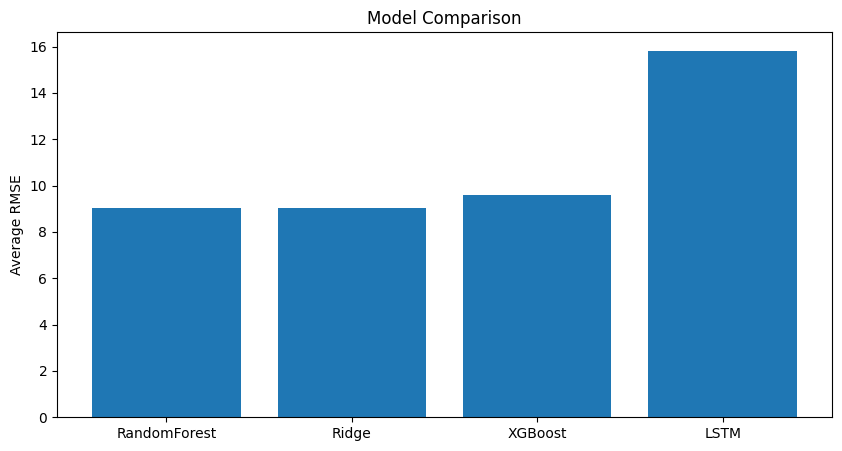

In [23]:
results = results.sort_values(
    "Avg_RMSE"
)

plt.figure(figsize=(10,5))

plt.bar(
    results["Model"],
    results["Avg_RMSE"]
)

plt.ylabel("Average RMSE")
plt.title("Model Comparison")

plt.show()

#### **Conclusion**

The comparative analysis of the four machine learning models indicates that Random Forest and Ridge Regression achieved the best predictive performance, both obtaining an average RMSE of approximately 9.0, demonstrating strong capability in forecasting future AQI levels. XGBoost also produced competitive results with a slightly higher average RMSE of around 9.6, indicating that its performance was comparable but marginally inferior on this dataset.

In contrast, the LSTM model recorded the highest prediction error with an average RMSE of approximately 15.8, suggesting that the available dataset size and feature set were insufficient for the deep learning model to fully exploit temporal patterns. This outcome highlights that more complex models do not necessarily guarantee superior performance, particularly when the dataset is relatively limited.

Overall, the results suggest that traditional machine learning approaches, especially Random Forest and Ridge Regression, are more suitable for AQI forecasting in this study, providing accurate predictions while maintaining lower computational complexity. These findings emphasize the importance of selecting models based on data characteristics rather than model sophistication alone.